In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
# Load Data
df_trx = pd.read_csv('Data/df_transaksi.csv')
df_nsb = pd.read_csv('Data/df_nasabah.csv')

# Konversi timestamp ke format datetime
df_trx['timestamp'] = pd.to_datetime(df_trx['timestamp'])
df_trx['bulan'] = df_trx['timestamp'].dt.month

print("✅ Data berhasil diload!")

✅ Data berhasil diload!


# 1) Validasi Demografi Nasabah

C:\Users\alden\AppData\Local\Temp\ipykernel_19408\2145239291.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_nsb, x='persona_dasar', palette='Set2')


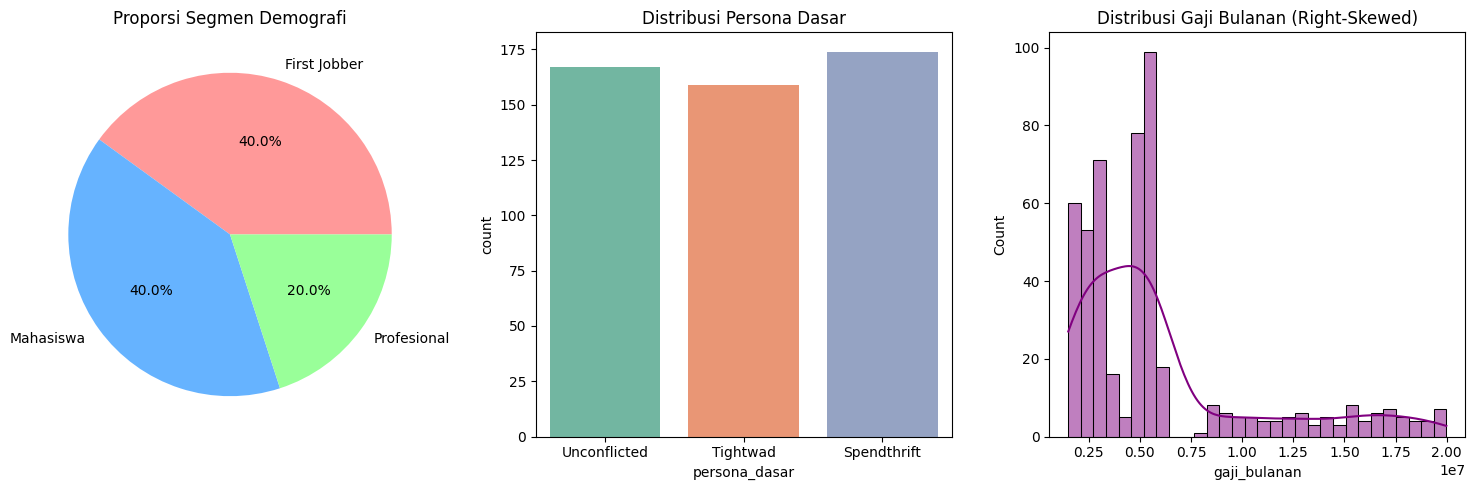

In [9]:
plt.figure(figsize=(15, 5))

# 1. Proporsi Demografi
plt.subplot(1, 3, 1)
df_nsb['segmen_demografi'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Proporsi Segmen Demografi')
plt.ylabel('')

# 2. Distribusi Persona Ground Truth
plt.subplot(1, 3, 2)
sns.countplot(data=df_nsb, x='persona_dasar', palette='Set2')
plt.title('Distribusi Persona Dasar')

# 3. Distribusi Gaji Bulanan
plt.subplot(1, 3, 3)
sns.histplot(df_nsb['gaji_bulanan'], bins=30, kde=True, color='purple')
plt.title('Distribusi Gaji Bulanan (Right-Skewed)')

plt.tight_layout()
plt.show()

- **Proporsi Sesuai Target:** Data nasabah berhasil dibangkitkan dengan porsi yang sangat presisi: 40% Mahasiswa, 40% First Jobber, dan 20% Profesional. Proporsi persona dasar juga tersebar merata (Spendthrift 34.8%, Unconflicted 33.4%, Tightwad 31.8%).  
- **Gaji Lognormal Terbukti:** Rata-rata gaji nasabah adalah Rp 5,9 Juta. Namun karena nilai maksimumnya mencapai nyaris Rp 20 Juta, ini membuktikan grafiknya right-skewed (menjulur ke kanan). Artinya, sistem berhasil mensimulasikan realita di mana mayoritas orang bergaji menengah/UMR, dan hanya segelintir (kaum Profesional) yang bergaji fantastis.

# 2) Validasi Perilaku Pilar 50/30/20

⏳ Menghitung Agregasi Pilar 50/30/20...


C:\Users\alden\AppData\Local\Temp\ipykernel_19408\476958038.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='persona_dasar', y=f, palette='Set3')
C:\Users\alden\AppData\Local\Temp\ipykernel_19408\476958038.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='persona_dasar', y=f, palette='Set3')
C:\Users\alden\AppData\Local\Temp\ipykernel_19408\476958038.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='persona_dasar', y=f, palette='Set3')


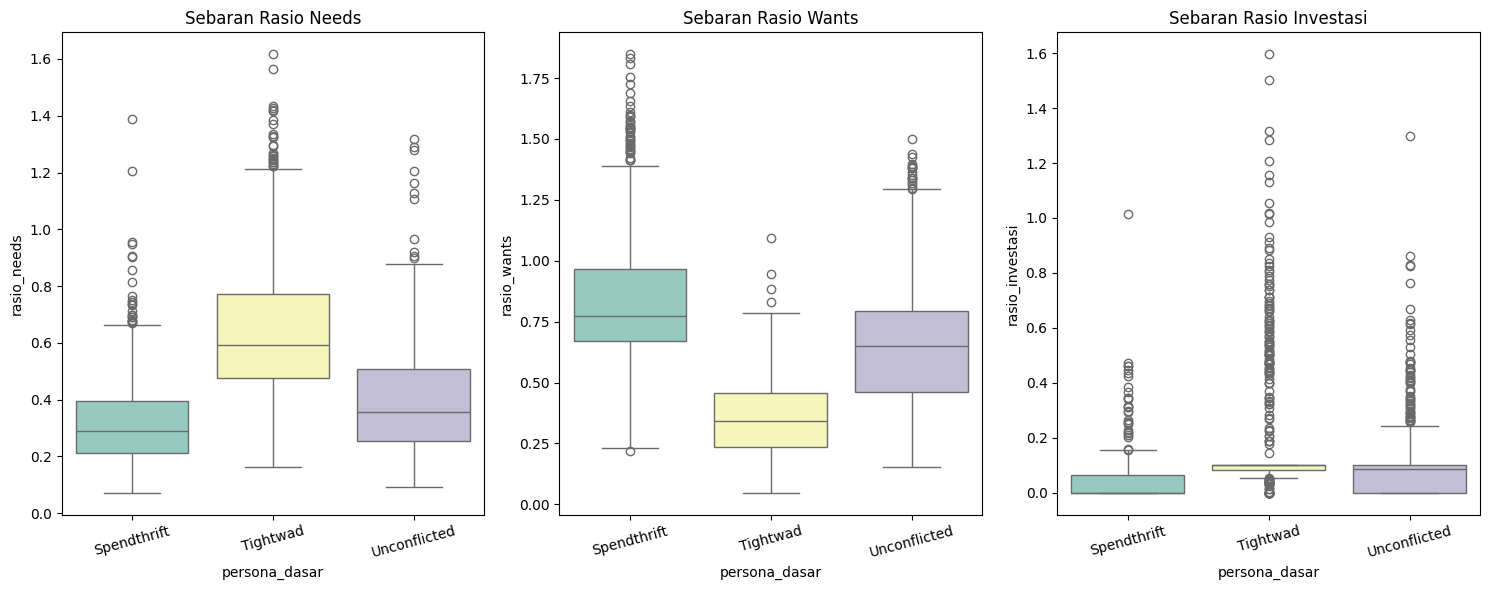

In [10]:
print("⏳ Menghitung Agregasi Pilar 50/30/20...")

# Mapping Kategori ke Pilar menggunakan Ground Truth Kategori
mapping_503020 = {
    'Tagihan & Utilitas': 'Needs', 'Transportasi': 'Needs', 'Groceries & Kebutuhan Pokok': 'Needs', 'Kesehatan & Perawatan Diri': 'Needs',
    'F&B dan Nongkrong': 'Wants', 'Hiburan & Langganan': 'Wants', 'Belanja Online & Fashion': 'Wants', 'Produktivitas & Digital': 'Wants', 'Transfer P2P': 'Wants',
    'Investasi & Finansial': 'Investasi'
}

df_trx['pilar_503020'] = df_trx['gt_kategori_detail'].map(mapping_503020)

# Agregasi Pemasukan dan Pengeluaran
df_in = df_trx[df_trx['tipe_mutasi'] == 'Kredit'].groupby(['id_user', 'bulan'])['nominal'].sum().reset_index(name='total_pemasukan')
df_out = df_trx[df_trx['tipe_mutasi'] == 'Debit'].pivot_table(index=['id_user', 'bulan'], columns='pilar_503020', values='nominal', aggfunc='sum', fill_value=0).reset_index()

# Gabung dan Hitung Rasio
df_user = pd.merge(df_in, df_out, on=['id_user', 'bulan'], how='left').fillna(0)
pemasukan_aman = df_user['total_pemasukan'].replace(0, np.nan)
df_user['rasio_needs'] = (df_user['Needs'] / pemasukan_aman).fillna(0)
df_user['rasio_wants'] = (df_user['Wants'] / pemasukan_aman).fillna(0)
df_user['rasio_investasi'] = (df_user['Investasi'] / pemasukan_aman).fillna(0)

# Gabung dengan Persona Asli dari df_nasabah
df_final = pd.merge(df_user, df_nsb[['id_user', 'persona_dasar']], on='id_user', how='inner')

# Visualisasi
plt.figure(figsize=(15, 6))
fitur = ['rasio_needs', 'rasio_wants', 'rasio_investasi']

for i, f in enumerate(fitur):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df_final, x='persona_dasar', y=f, palette='Set3')
    plt.title(f'Sebaran {f.replace("_", " ").title()}')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

**- Spendthrift Memang "Bocor":** Mereka mencatatkan rasio pengeluaran Wants rata-rata sebesar 84.9% dari gaji mereka! Jauh meninggalkan kebutuhan pokok (Needs) yang hanya 32.7%. Ini membuktikan mereka foya-foya tanpa rem.  
**- Tightwad Sangat Konservatif:** Sesuai tebakan, Tightwad sangat pelit untuk Wants (hanya 35.3%) dan paling sadar akan hari tua dengan rasio Investasi tertinggi mencapai 19.8% (mendekati target rasio ideal 20%).  
**- Unconflicted Berada di Tengah:** Proporsi mereka stabil dan moderat di antara kedua kubu ekstrem tersebut.

# 3) Investigasi Jebakan Anomali Harga

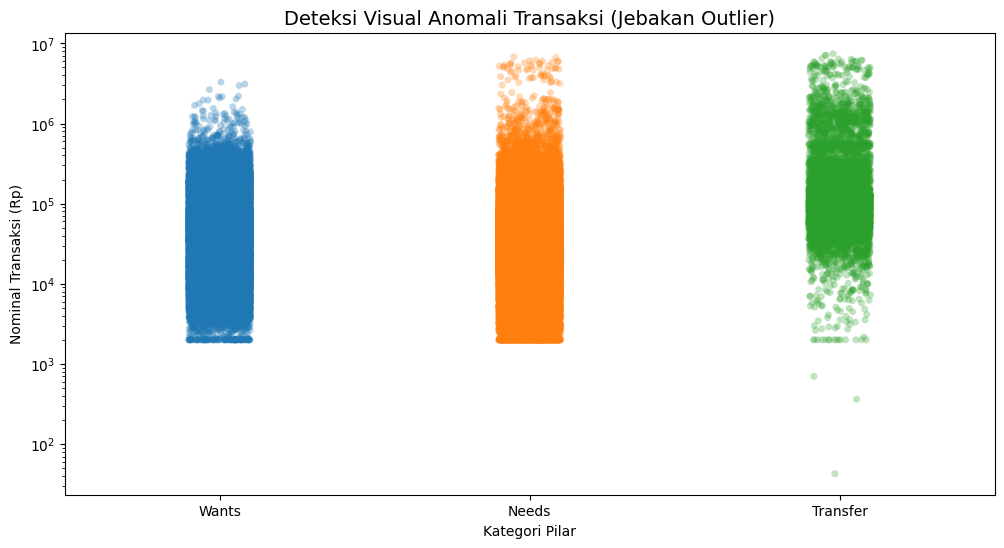

In [11]:
plt.figure(figsize=(12, 6))

# Filter hanya pengeluaran (Debit)
df_debit = df_trx[df_trx['tipe_mutasi'] == 'Debit'].copy()

# Scatter plot nominal berdasarkan pilar
sns.stripplot(data=df_debit, x='gt_kategori_besar', y='nominal',
              hue='gt_kategori_besar', jitter=True, alpha=0.3, legend=False)

plt.title('Deteksi Visual Anomali Transaksi (Jebakan Outlier)', fontsize=14)
plt.ylabel('Nominal Transaksi (Rp)')
plt.xlabel('Kategori Pilar')
# Gunakan log-scale agar anomali dengan harga berjuta-juta bisa terlihat "lepas" dari awan utama
plt.yscale('log')
plt.show()

- **Efek multiplier acak** (anomali harga) kita sangat terlihat jelas!
- **Rata-rata normal untuk pengeluaran Needs** hanyalah Rp 56.787 dan Wants sekitar Rp 68.277.  
- TAPI, algoritma kita berhasil menciptakan **transaksi pencilan ekstrem**(outliers)! Terdapat transaksi Needs yang mencapai Rp 6,7 Juta, dan transaksi Wants (gaya hidup) yang menembus Rp 3,2 Juta. Anomali buta inilah yang nanti akan menghancurkan skor K-Means dan membuktikan K-Medoids adalah juaranya.

# 4) Validasi Dinamika Sisa Saldo

C:\Users\alden\AppData\Local\Temp\ipykernel_19408\2448647005.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_saldo_akhir, x='persona_dasar', y='rasio_sisa_uang', errorbar='sd', palette='pastel')


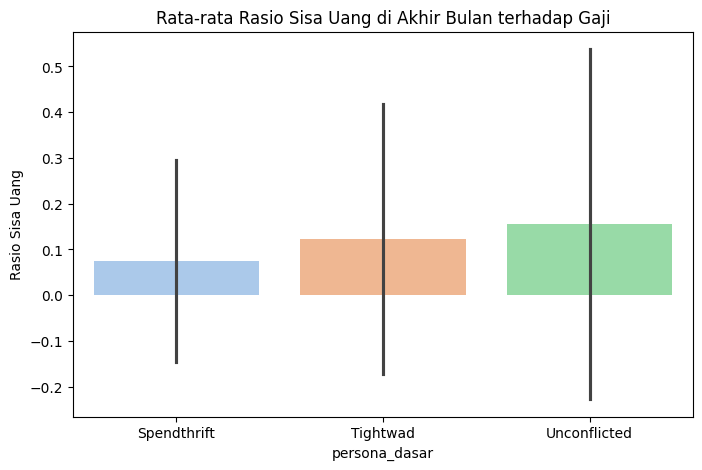

In [12]:
# Ambil transaksi hari terakhir untuk setiap bulan tiap nasabah
df_saldo_akhir = df_trx.sort_values('timestamp').groupby(['id_user', 'bulan']).tail(1)
df_saldo_akhir = pd.merge(df_saldo_akhir[['id_user', 'bulan', 'sisa_saldo']],
                          df_nsb[['id_user', 'persona_dasar', 'gaji_bulanan']], on='id_user')

# Hitung rasio sisa uang terhadap gaji
df_saldo_akhir['rasio_sisa_uang'] = df_saldo_akhir['sisa_saldo'] / df_saldo_akhir['gaji_bulanan']

plt.figure(figsize=(8, 5))
sns.barplot(data=df_saldo_akhir, x='persona_dasar', y='rasio_sisa_uang', errorbar='sd', palette='pastel')
plt.title('Rata-rata Rasio Sisa Uang di Akhir Bulan terhadap Gaji')
plt.ylabel('Rasio Sisa Uang')
plt.show()

- Spendthrift Menjerit di Akhir Bulan: Karena limit belanjanya dilepas, rata-rata sisa uang Spendthrift di akhir bulan (tanggal 30/31) sangat menyedihkan, yaitu hanya tersisa 7.5% dari total gajinya! (Bayangkan kalau gaji Rp 3 juta, sisa uangnya cuma Rp 225 ribu).  
- Di sisi lain, Unconflicted dan Tightwad jauh lebih sejahtera karena sisa uang mereka masih bertahan di angka 12% hingga 15.5%.